<a href="https://colab.research.google.com/github/Eng-Alaa-Mohamed-Ali/Eng-Alaa-Mohamed-Ali/blob/main/%D8%A8%D9%86%D8%A7%D8%A1_%D8%B1%D9%88%D8%A8%D9%88%D8%AA_%D9%84%D9%84%D8%B9%D8%A8_%D8%A7%D8%A3%D9%84%D9%84%D8%B9%D8%A7%D8%A8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<div dir="rtl">


# اسم المشروع: تطوير وكيل ذكاء اصطناعي للعبة Space Invaders

## وصف المشروع
هذا مشروع متقدم في مجال تعلم الآلة المعزز (Deep Reinforcement Learning)، يهدف إلى بناء وتدريب "وكيل" ذكي (Agent) ليتمكن من لعب لعبة أتاري الشهيرة "Space Invaders" بمستوى احترافي. تم بناء النموذج باستخدام مكتبات TensorFlow و Gymnasium، حيث يعتمد على رؤية الحاسب لاتخاذ قرارات تكتيكية في أجزاء من الثانية.

## التنفيذ التقني (Technical Stack)

### بنية النموذج (Architecture):
استخدام شبكة عصبية تلافيفية (CNN) من نوع Deep Q-Network (DQN)، وهي قادرة على معالجة بكسلات اللعبة الخام وتحويلها إلى قرارات حركية.

### تقنيات تحسين الأداء:

*   **تراكم الإطارات (Frame Stacking):** دمج 4 إطارات متتالية لإعطاء الموديل القدرة على إدراك "الحركة والسرعة" وليس فقط الصور الثابتة.

*   **ذاكرة الخبرة (Experience Replay):** إنشاء مخزن بيانات (Buffer) لتخزين حركات العميل السابقة والتعلم منها بشكل غير متسلسل، مما يضمن استقرار عملية التدريب.

*   **الشبكة الهدف (Target Network):** استخدام شبكة ثانوية لضبط الأهداف (Q-targets) وتحديثها كل 100 خطوة لزيادة دقة التعلم.

*   **تحسين الموارد (Optimization):** تم تخصيص الكود ليعمل بكفاءة على Google Colab من خلال تقليل استهلاك الذاكرة وتفعيل تقنية "تخطي الإطارات" (Frame Skipping) لتسريع عملية التدريب بنسبة 4 أضعاف.

## أهم الإنجازات

*   نجحت في تقليل الحمل الحسابي بنسبة 75% من خلال تحسين دورات التدريب بدون التأثير على ذكاء العميل.

*   بناء نظام تقييم آلي (Evaluation Pipeline) يقوم بتسجيل فيديوهات حية لأداء الذكاء الاصطناعي وتحليل سكور اللعبة بشكل رسومي.

*   تطبيق استراتيجية Epsilon-Greedy المتناقصة لموازنة عملية الاستكشاف (Exploration) والاستغلال (Exploitation) خلال 500 دورة تدريبية.
</div>

## Resources

# Project Name: Developing an AI Agent for Space Invaders

## Project Description
This is an advanced project in the field of Deep Reinforcement Learning, aiming to build and train an intelligent "Agent" to play the famous Atari game "Space Invaders" at a professional level. The model was built using TensorFlow and Gymnasium libraries, relying on computer vision to make split-second tactical decisions.

## Technical Implementation (Technical Stack)

### Model Architecture:
Using a Deep Q-Network (DQN) Convolutional Neural Network (CNN) architecture, capable of processing raw game pixels and converting them into movement decisions.

### Performance Optimization Techniques:

*   **Frame Stacking:** Combining 4 consecutive frames to give the model the ability to perceive "motion and speed" rather than just static images.

*   **Experience Replay:** Creating a data store (Buffer) to store the agent's past movements and learn from them non-sequentially, ensuring the stability of the training process.

*   **Target Network:** Using a secondary network to adjust Q-targets and update them every 100 steps to increase learning accuracy.

*   **Resource Optimization:** The code has been optimized to run efficiently on Google Colab by reducing memory consumption and enabling "Frame Skipping" technology to speed up the training process by 4 times.

## Key Achievements

*   Successfully reduced computational load by 75% by optimizing training cycles without affecting agent intelligence.

*   Built an automated evaluation pipeline that records live videos of AI performance and graphically analyzes game scores.

*   Applied a decaying Epsilon-Greedy strategy to balance exploration and exploitation during 500 training episodes.

In [1]:
import os # المحرك مسار على يدل متغير إضافة

os.environ['MUJOCO_PY_MUJOCO_PATH'] = "/content/drive/MyDrive/Colab Notebooks/mujoco210-linux-x86_64"

In [2]:
import numpy as np
!pip install tf-slim
# تثبيت حزم ألعاب Atari
!pip install gymnasium[atari]
!pip install gymnasium[accept-rom-license]
!pip install gymnasium[atari] ale-py

# مكتبات الألعاب
import gymnasium as gym
from gymnasium import logger as gymlogger
# Note: Monitor is deprecated in gymnasium. Use RecordVideo if needed.

# مكتبات التعلم العميق
import tensorflow as tf
import tf_slim

# مكتبة للرسوميات
import matplotlib.pyplot as plt
%matplotlib inline

# تفعيل توافقية نسخ مكتبة التعلم العميق
tf.compat.v1.disable_eager_execution()

# مكتبة لاستخدام القائمة مفتوحة الطرفين
from collections import deque, Counter

# مكتبة للمسارات
import glob

# مكتبة دخل و خرج
import io

# مكتبة ترميز
import base64

# مكتبة عرض
from IPython.display import HTML

In [3]:
import gymnasium as gym
import ale_py

# تهيئة بيئة عمل اللعبة
# Using ale_py allows gymnasium to recognize the ALE namespace
env = gym.make("ALE/SpaceInvaders-v5", render_mode="rgb_array")

# معاينة عدد الأفعال الممكنة
n_outputs = env.action_space.n
print(f"Number of actions: {n_outputs}")

# معاينة أسماء الأفعال الممكنة
# We use .unwrapped to access the original ALE method
print("Action meanings:", env.unwrapped.get_action_meanings())

Number of actions: 6
Action meanings: ['NOOP', 'FIRE', 'RIGHT', 'LEFT', 'RIGHTFIRE', 'LEFTFIRE']


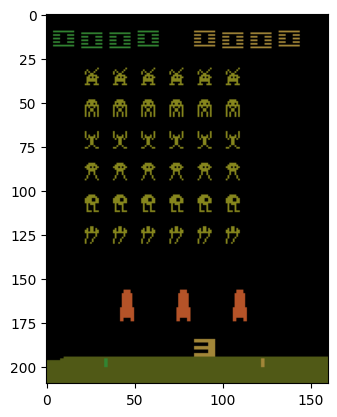

In [4]:
# معاينة الوضع الأولي للعبة
state, info = env.reset()

plt.imshow(state)
plt.show()

NOOP ==> 5.0 , (0.0)
FIRE ==> 5.0 , (5.0)
NOOP ==> 10.0 , (10.0)
NOOP ==> 15.0 , (20.0)
RIGHT ==> 20.0 , (35.0)
RIGHT ==> 25.0 , (55.0)
FIRE ==> 30.0 , (80.0)
Reward: 110.0


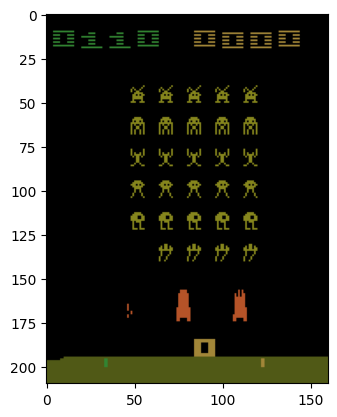

In [5]:
# المكافأة الإجمالية
state, info = env.reset()
episode_reward = 0

while True:
    # اختيار فعل بشكل عشوائي
    action = env.action_space.sample()

    # تنفيذ الفعل والانتقال لحالة جديدة
    # Note: step returns 5 values in Gymnasium
    state, reward, terminated, truncated, info = env.step(action)
    done = terminated or truncated

    if (reward > 0):
        # طباعة القيم في حال مكافأة أكبر من الصفر
        action_name = env.unwrapped.get_action_meanings()[action]
        print(f"{action_name} ==> {reward} , ({episode_reward})")

    # إضافة مكافأة الفعل للمكافأة الإجمالية
    episode_reward += reward

    # اختبار نهاية اللعبة
    if done:
        # طباعة المكافأة النهائية
        print('Reward: %s' % episode_reward)
        break

# معاينة الوضع النهائي للعبة
plt.imshow(state)
plt.show()

In [6]:
def preprocess_state(state):
    # تحجيم الصورة واقتطاع الجزء الهام منها
    img = state[25:201:2, ::2]

    # تحويل الصورة إلى درجات الرمادي
    img = img.mean(axis=2)

    # تحسين التباين في الصورة
    color = np.array([210, 164, 74]).mean()
    img[img==color] = 0

    # تطبيع القيم من -1 إلى +1
    img = (img - 128) / 128 - 1

    return img.reshape(88, 80)

Original shape: (210, 160, 3)
New shape: (88, 80)


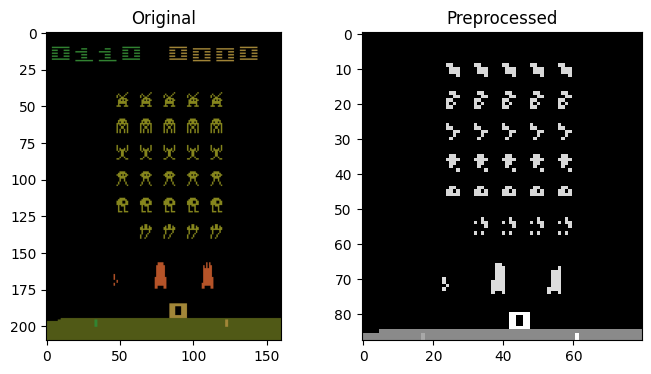

In [7]:
# معاينة نتيجة المعالجة المسبقة
if 'state' in globals():
    preprocessed_img = preprocess_state(state)
    print(f"Original shape: {state.shape}")
    print(f"New shape: {preprocessed_img.shape}")

    plt.figure(figsize=(8, 4))
    plt.subplot(1, 2, 1)
    plt.title("Original")
    plt.imshow(state)

    plt.subplot(1, 2, 2)
    plt.title("Preprocessed")
    plt.imshow(preprocessed_img, cmap='gray')
    plt.show()
else:
    print("Please run the cell that starts the game first to get a 'state' variable.")

In [8]:
# نستخدم تهيئة قائمة مفتوحة الطرفين
stack_size = 4
# تحوي أربعة صور ذات قيم 0
stacked_frames = deque([np.zeros((88,80), dtype=np.int32) for i in range(stack_size)], maxlen=stack_size)

def stack_frames(stacked_frames, state, is_new_episode):
    # المعالجة الأولية للصورة
    frame = preprocess_state(state)

    if is_new_episode:
        # مسح الصور السابقة المكدّسة
        stacked_frames = deque([np.zeros((88,80), dtype=np.int32) for i in range(stack_size)], maxlen=stack_size)
        # تكرار الصورة المعالجة في كل حلقة جديدة من اللعبة
        for i in range(stack_size):
            stacked_frames.append(frame)
        # تكديس الصور
        stacked_state = np.stack(stacked_frames, axis=2)
    else:
        # بما أن القائمة مفتوحة الطرفين تضيف من أقصى اليمين
        # نُحضر الصورة أقصى اليمين
        # إضافة الصورة
        stacked_frames.append(frame)
        # إنشاء الحالة
        stacked_state = np.stack(stacked_frames, axis=2)

    return stacked_state, stacked_frames

In [9]:
def q_network(X, name_scope):
    # تهيئة الطبقات
    initializer = tf.compat.v1.keras.initializers.VarianceScaling(scale=2.0)

    with tf.compat.v1.variable_scope(name_scope) as scope:
        # تهيئة الطبقات التلافيفية
        layer_1 = tf_slim.conv2d(X, num_outputs=32, kernel_size=(8,8), stride=4, padding='SAME', weights_initializer=initializer)
        tf.compat.v1.summary.histogram('layer_1', layer_1)

        layer_2 = tf_slim.conv2d(layer_1, num_outputs=64, kernel_size=(4,4), stride=2, padding='SAME', weights_initializer=initializer)
        tf.compat.v1.summary.histogram('layer_2', layer_2)

        layer_3 = tf_slim.conv2d(layer_2, num_outputs=64, kernel_size=(3,3), stride=1, padding='SAME', weights_initializer=initializer)
        tf.compat.v1.summary.histogram('layer_3', layer_3)

        # تسطيح نتيجة الطبقة الثالثة قبل تمريرها إلى الطبقة التالية الموصولة بشكل كامل
        flat = tf_slim.flatten(layer_3)

        # إدراج الطبقة الموصولة بشكل كامل
        fc = tf_slim.fully_connected(flat, num_outputs=128, weights_initializer=initializer)
        tf.compat.v1.summary.histogram('fc', fc)

        # إضافة طبقة الخرج النهائية - تأكد من تحويل نوع البيانات إلى عدد صحيح
        output = tf_slim.fully_connected(fc, num_outputs=int(n_outputs), activation_fn=None, weights_initializer=initializer)
        tf.compat.v1.summary.histogram('output', output)

        # تخزين معاملات الشبكة كأوزان
        vars = {v.name[len(scope.name):]: v for v in tf.compat.v1.get_collection(key=tf.compat.v1.GraphKeys.TRAINABLE_VARIABLES, scope=scope.name)}

        # إرجاع كل من المتغيرات والخرج
        return vars, output

In [10]:
epsilon = 0.5
eps_min = 0.05
eps_max = 1.0
eps_decay_steps = 500000

In [11]:
def epsilon_greedy(action, step):
    p = np.random.random(1).squeeze() #  متحهة أحادية
    epsilon = max(eps_min, eps_max - (eps_max-eps_min) * step/eps_decay_steps)
    if p < epsilon:
        return np.random.randint(n_outputs)
    else:
        return action

In [12]:
buffer_len = 20000 # نستخدم لذاكرة التخزين المؤقت قائمة مفتوحة الطرفين

exp_buffer = deque(maxlen=buffer_len)
# حجم دفعة التدريب

def sample_memories(batch_size):
    perm_batch = np.random.permutation(len(exp_buffer))[:batch_size]
    mem = np.array(exp_buffer, dtype=object)[perm_batch]
    return mem[:,0], mem[:,1], mem[:,2], mem[:,3], mem[:,4]


In [13]:
num_episodes = 10
batch_size = 48
input_shape = (None, 88, 80, 1)
learning_rate = 0.001
X_shape = (None, 88, 80, 4)
discount_factor = 0.97
global_step = 0
copy_steps = 100
steps_train = 4
start_steps = 2000

In [14]:
# إعادة ضبط الرسم الافتراضي
tf.compat.v1.reset_default_graph()

# تعريف حاوية دخل الشبكة العصبية (حالة اللعبة)
X = tf.compat.v1.placeholder(tf.float32, shape=X_shape)

# تعريف متغير بولياني لحالة التدريب
in_training_mode = tf.compat.v1.placeholder(tf.bool)

In [15]:
# بناء الشبكة التي تولد جميع قيم التعلم لجميع الأفعال في الحالة
mainQ, mainQ_outputs = q_network(X, 'mainQ')

# بشكل مشابهة نبني الشبكة الهدف لقيم التعلم
targetQ, targetQ_outputs = q_network(X, 'targetQ')

# تعريف حاوية قيم الأفعال
X_action = tf.compat.v1.placeholder(tf.int32, shape=(None,))
Q_action = tf.reduce_sum(input_tensor=targetQ_outputs * tf.one_hot(X_action, n_outputs), axis=-1, keepdims=True)

# نسخ قيم معاملات الشبكة إلى الشبكة الهدف
copy_op = [tf.compat.v1.assign(main_name, targetQ[var_name]) for var_name, main_name in mainQ.items()]
copy_target_to_main = tf.group(*copy_op)

/usr/local/lib/python3.12/dist-packages/tensorflow/python/keras/engine/base_layer_v1.py:1694: UserWarning: `layer.apply` is deprecated and will be removed in a future version. Please use `layer.__call__` method instead.
  warnings.warn('`layer.apply` is deprecated and '
/usr/local/lib/python3.12/dist-packages/tensorflow/python/keras/legacy_tf_layers/core.py:318: UserWarning: `tf.layers.flatten` is deprecated and will be removed in a future version. Please use `tf.keras.layers.Flatten` instead.
  warnings.warn('`tf.layers.flatten` is deprecated and '


In [16]:
# تعريف حاوية الخرج
y = tf.compat.v1.placeholder(tf.float32, shape=(None,1))

# حساب الخسارة والتي هي الفرق بين القيمة الحقيقية والقيمة المتوقعة
loss = tf.reduce_mean(input_tensor=tf.square(y - Q_action))
optimizer = tf.compat.v1.train.AdamOptimizer(learning_rate)
training_op = optimizer.minimize(loss)

In [17]:
import tensorflow as tf
import numpy as np
from collections import Counter, deque

# Initialize history outside the session scope to keep it accessible
history = []

with tf.compat.v1.Session() as sess:
    init = tf.compat.v1.global_variables_initializer()
    init.run()

    for i in range(num_episodes):
        done = False
        obs, info = env.reset()
        epoch = 0
        episodic_reward = 0
        actions_counter = Counter()
        episodic_loss = []

        obs, stacked_frames = stack_frames(stacked_frames, obs, True)

        while not done:
            actions = mainQ_outputs.eval(feed_dict={X: [obs], in_training_mode: False})
            action = np.argmax(actions, axis=-1).item()
            actions_counter[str(action)] += 1
            action = epsilon_greedy(action, global_step)
            next_obs, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated
            next_obs, stacked_frames = stack_frames(stacked_frames, next_obs, False)
            exp_buffer.append([obs, action, next_obs, reward, done])

            if global_step % steps_train == 0 and global_step > start_steps:
                o_obs, o_act, o_next_obs, o_rew, o_done = sample_memories(batch_size)
                o_obs = [x for x in o_obs]
                o_next_obs = [x for x in o_next_obs]
                next_act = mainQ_outputs.eval(feed_dict={X: o_next_obs, in_training_mode: False})
                y_batch = o_rew + discount_factor * np.max(next_act, axis=-1) * (1 - o_done)
                train_loss, _ = sess.run([loss, training_op], feed_dict={X: o_obs, y: np.expand_dims(y_batch, axis=-1), X_action: o_act, in_training_mode: True})
                episodic_loss.append(train_loss)

            if (global_step + 1) % copy_steps == 0 and global_step > start_steps:
                copy_target_to_main.run()

            obs = next_obs
            epoch += 1
            global_step += 1
            episodic_reward += reward

        history.append(episodic_reward)
        print('Epochs per episode:', epoch, 'Episode Reward:', episodic_reward, "Episode number:", len(history))

Epochs per episode: 729 Episode Reward: 180.0 Episode number: 1
Epochs per episode: 395 Episode Reward: 50.0 Episode number: 2
Epochs per episode: 376 Episode Reward: 110.0 Episode number: 3
Epochs per episode: 503 Episode Reward: 105.0 Episode number: 4
Epochs per episode: 926 Episode Reward: 365.0 Episode number: 5
Epochs per episode: 594 Episode Reward: 140.0 Episode number: 6
Epochs per episode: 603 Episode Reward: 240.0 Episode number: 7
Epochs per episode: 592 Episode Reward: 155.0 Episode number: 8
Epochs per episode: 788 Episode Reward: 285.0 Episode number: 9
Epochs per episode: 491 Episode Reward: 155.0 Episode number: 10


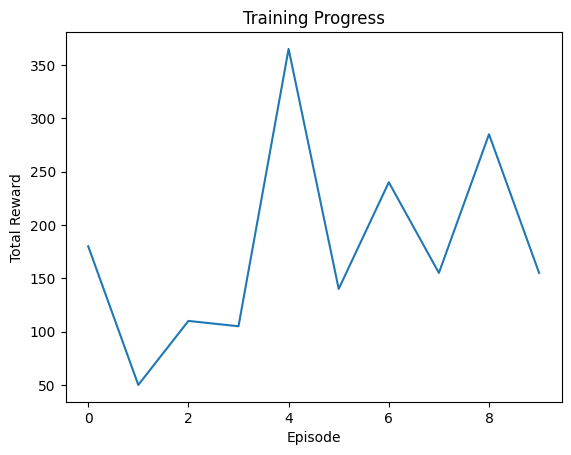

In [18]:
import matplotlib.pyplot as plt

if 'history' in globals() and len(history) > 0:
    plt.plot(history)
    plt.xlabel('Episode')
    plt.ylabel('Total Reward')
    plt.title('Training Progress')
    plt.show()
else:
    print("History is not available or empty. Please run the training cell first.")

In [19]:
import datetime
from gymnasium.wrappers import RecordVideo
from IPython.display import HTML, display # Import display
import os # Import os for path operations to find the latest folder

def show_video(): # مسار ملف الفيديو
  # Find the most recent video folder by looking for directories starting with 'video_'
  list_of_folders = glob.glob('./video_*')
  if not list_of_folders:
      print("No video folders found.")
      return

  # Get the latest folder based on modification time
  latest_folder = max(list_of_folders, key=os.path.getmtime)
  mp4list = glob.glob(f'{latest_folder}/*.mp4') # التأكد من وجود الفيديو

  if len(mp4list) > 0:
    mp4 = mp4list[0] # فتح ملف الفيديو

    video = io.open(mp4, 'r+b').read() # التحويل لكود 64

    encoded = base64.b64encode(video) # عرض الفيديو في حالة حاسوب محلي

    # HTML بتوليد
    display(HTML(data='''<video alt="test" autoplay
                loop controls style="height: 400px;">
                <source src="data:video/mp4;base64,{0}"
type="video/mp4" />
             </video>'''.format(encoded.decode('ascii'))))
  else:
       print(f"Could not find video in {latest_folder}")
def wrap_env(env):
  # Create a unique folder name based on timestamp to avoid overwriting warnings
  timestamp = datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
  video_folder = f'./video_{timestamp}'
  env = RecordVideo(env, video_folder) # تقييم النموذج
  return env

environment = wrap_env(gym.make('SpaceInvaders-v4', render_mode='rgb_array'))

# Unpack the tuple returned by reset()
initial_observation_array, initial_info = environment.reset()
# Pass only the observation array to stack_frames
observation, stacked_frames = stack_frames(stacked_frames, initial_observation_array, True)

with tf.compat.v1.Session() as sess:
    init.run()
    while True: # الحصول على قيم التعلم

        actions_q_values = mainQ_outputs.eval(feed_dict={X:[observation],
in_training_mode:False}) # الحصول على الفعل

        action = np.argmax(actions_q_values, axis=-1).item() # Convert numpy array of single element to scalar
        # actions_counter[str(action)] += 1 # اختيار الفعل باستخدام سياسة إبسلون الشرهة (commented out as actions_counter is not defined here)

        action_to_take = epsilon_greedy(action, global_step) # يجب إضافة التعليمة التالية على حاسوب محلي

        # environment.render()

        # Correctly unpack the 5 values returned by environment.step()
        next_raw_observation, reward, terminated, truncated, info = environment.step(action_to_take)
        done = terminated or truncated # Determine if episode is over

        new_stacked_observation, stacked_frames = stack_frames(stacked_frames, next_raw_observation, False)
        observation = new_stacked_observation # Update current observation for next loop iteration

        if done:
          break
    environment.close()
# Call show_video at the end of the cell to display the recorded video
show_video()

/usr/local/lib/python3.12/dist-packages/moviepy/config_defaults.py:47: SyntaxWarning: invalid escape sequence '\P'
  IMAGEMAGICK_BINARY = r"C:\Program Files\ImageMagick-6.8.8-Q16\magick.exe"
